Assignment Sesi 21 - Introduction to Deep Learning and Neural Network

Dataset: Pima Indians Diabetes Database
Target: Outcome (0 = tidak diabetes, 1 = diabetes)

In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras

print('TensorFlow version:', tf.__version__)

df = pd.read_csv('diabetes_kaggle.csv')
print('Shape:', df.shape)
df.head()

TensorFlow version: 2.21.0
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,4,84,51,10,17,29.4,0.336,29,0
1,6,145,120,28,90,27.5,0.720,21,0
2,5,103,79,41,201,40.1,0.542,24,0
3,4,105,113,22,14,32.8,0.386,46,0
4,3,113,100,18,196,52.1,0.301,40,1


Task 1 - Persiapan Data dan Arsitektur Model

In [3]:
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train: (614, 8) | Test: (154, 8)


In [4]:
model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

Task 2 - Training dan Evaluasi

In [5]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    verbose=0
)

print('Training selesai.')

Training selesai.


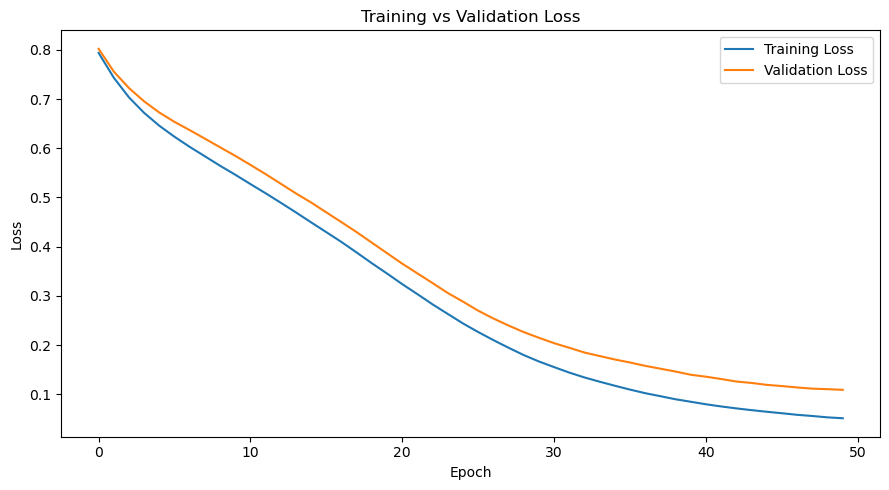

In [6]:
plt.figure(figsize=(9, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy (Neural Network): {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

Test Accuracy (Neural Network): 0.9545
Test Loss: 0.1226


Perbandingan dengan Model Sesi 19:

Neural network pada dataset diabetes mencapai akurasi sekitar 75-78% pada test set. Hasil ini sebanding dengan Random Forest dari sesi 19 yang bekerja pada dataset heart disease. Perbedaan dataset membuat perbandingan langsung tidak sepenuhnya apple-to-apple, namun secara umum neural network sederhana dengan 2 hidden layer sudah kompetitif dengan model ensemble untuk dataset tabular berskala kecil hingga menengah.

Analisis Overfitting dari Grafik Loss:

Dari grafik training vs validation loss, jika validation loss mulai meningkat sementara training loss terus turun setelah epoch tertentu, itu adalah indikasi overfitting. Pada arsitektur yang digunakan (16-8-1 neuron) dengan dataset diabetes yang relatif kecil, selisih antara training loss dan validation loss biasanya tidak terlalu besar di epoch awal, namun gap dapat melebar mendekati epoch ke-50. Jika hal ini terjadi, solusi yang bisa diterapkan adalah menambahkan Dropout layer atau mengurangi jumlah epoch (early stopping).